# (1) Introduction

In [8]:
import pandas as pd
# Pandas DataFrame
data = {
    'Name':['A', 'B', 'C', 'D'],
    'Gender':['M','F','M','F']
}
data = pd.DataFrame(data)
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [7]:
name_series = data[['Name']]
gender_series = data[['Gender']]

new_df = pd.concat(
    [name_series, gender_series],
    axis = 1
)
new_df

,Name,Gender
0,A,M
1,B,F
2,C,M
3,D,F


# PROBLEM A

- IMDB-Movie-Dataset

In [34]:
dataset_path = r'C:\Code_AI\AIO_Code\Module3\Pandas\IMDB-Movie-Data.csv'
data = pd.read_csv(dataset_path)
data_indexed = pd.read_csv(dataset_path, index_col='Title')
data_indexed.head(3)

,Rank,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
Title,,,,,,,,,,,
Guardians of the Galaxy,1,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
Prometheus,2,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
Split,3,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0


In [13]:
# View data information and statistic summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [14]:
data.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


In [ ]:
extracted_df = data[['Rank', 'Year', 'Rating', 'Votes']]
extracted_df.head(2)

,Rank,Year,Rating,Votes
0,1,2014,8.1,757074
1,2,2012,7.0,485820


In [25]:
# Data Selection: Slicing
data.iloc[10:15][['Rank', 'Title']]

,Rank,Title
10,11,Fantastic Beasts and Where to Find Them
11,12,Hidden Figures
12,13,Rogue One
13,14,Moana
14,15,Colossal


In [38]:
# Select all movies publish between 2010 and 2015, have rating less than 6.0
# and revenue over 95'th percentile of dataset

df = data.loc[((data['Year'] >= 2010) & (data['Year'] <= 2015))
         & (data['Rating'] < 6.0)
         & (data['Revenue (Millions)'] > data['Revenue (Millions)'].quantile(0.95))]
df

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
941,942,The Twilight Saga: Eclipse,"Adventure,Drama,Fantasy",As a string of mysterious killings grips Seatt...,David Slade,"Kristen Stewart, Robert Pattinson, Taylor Laut...",2010,124,4.9,192740,300.52,58.0


In [ ]:
df = data.loc[
    data['Year'].between(2010, 2015) & 
    (data['Rating'] < 6.0) & 
    (data['Revenue (Millions)'] > data['Revenue (Millions)'].quantile(0.95))
]
df

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
941,942,The Twilight Saga: Eclipse,"Adventure,Drama,Fantasy",As a string of mysterious killings grips Seatt...,David Slade,"Kristen Stewart, Robert Pattinson, Taylor Laut...",2010,124,4.9,192740,300.52,58.0


In [44]:
# Groupby Operations
print(data[['Director', 'Rating']].head())
data.groupby('Director')[['Rating']].mean().head(5)

               Director  Rating
0            James Gunn     8.1
1          Ridley Scott     7.0
2    M. Night Shyamalan     7.3
3  Christophe Lourdelet     7.2
4            David Ayer     6.2


,Rating
Director,
Aamir Khan,8.5
Abdellatif Kechiche,7.8
Adam Leon,6.5
Adam McKay,7.0
Adam Shankman,6.3


In [46]:
x = data.groupby('Director')[['Rating']].mean()
x.sort_values('Rating', ascending=False).head()

,Rating
Director,
Nitesh Tiwari,8.80
Christopher Nolan,8.68
Olivier Nakache,8.60
Makoto Shinkai,8.60
Florian Henckel von Donnersmarck,8.50


In [ ]:
# Dealing with missing values
# To check null values 
data.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

In [50]:
# Apply function
# Classify movies based on ratings
def rating_group(rating):
    if rating >= 7.5:
        return 'Good'
    elif rating >= 6.0:
        return 'Average'
    else:
        return 'Bad'

# Lets apply this function on dataset
# creating a new variable in the dataset to hold the rating category
data['Rating_category'] = data['Rating'].apply(rating_group)
data[['Title', 'Director', 'Rating', 'Rating_category']].head()

,Title,Director,Rating,Rating_category
0,Guardians of the Galaxy,James Gunn,8.1,Good
1,Prometheus,Ridley Scott,7.0,Average
2,Split,M. Night Shyamalan,7.3,Average
3,Sing,Christophe Lourdelet,7.2,Average
4,Suicide Squad,David Ayer,6.2,Average


# PROBLEM B
- Given Open Power System Germany Daily dataset, do some analysis using Pandas: Time-based indexing, extracting seasonality, frequencies, resampling, rolling windows, trends, visualization

In [52]:
data_path = r'C:\Code_AI\AIO_Code\Module3\Pandas\opsd_germany_daily.csv'
opsd_daily = pd.read_csv(data_path)
print(opsd_daily.shape)
print(opsd_daily.dtypes)
opsd_daily.head(3)

(4383, 5)
Date            object
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object


,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.184,NaN,NaN,NaN
1,2006-01-02,1380.521,NaN,NaN,NaN
2,2006-01-03,1442.533,NaN,NaN,NaN


In [53]:
opsd_daily = opsd_daily.set_index('Date')
opsd_daily.head(3)

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN


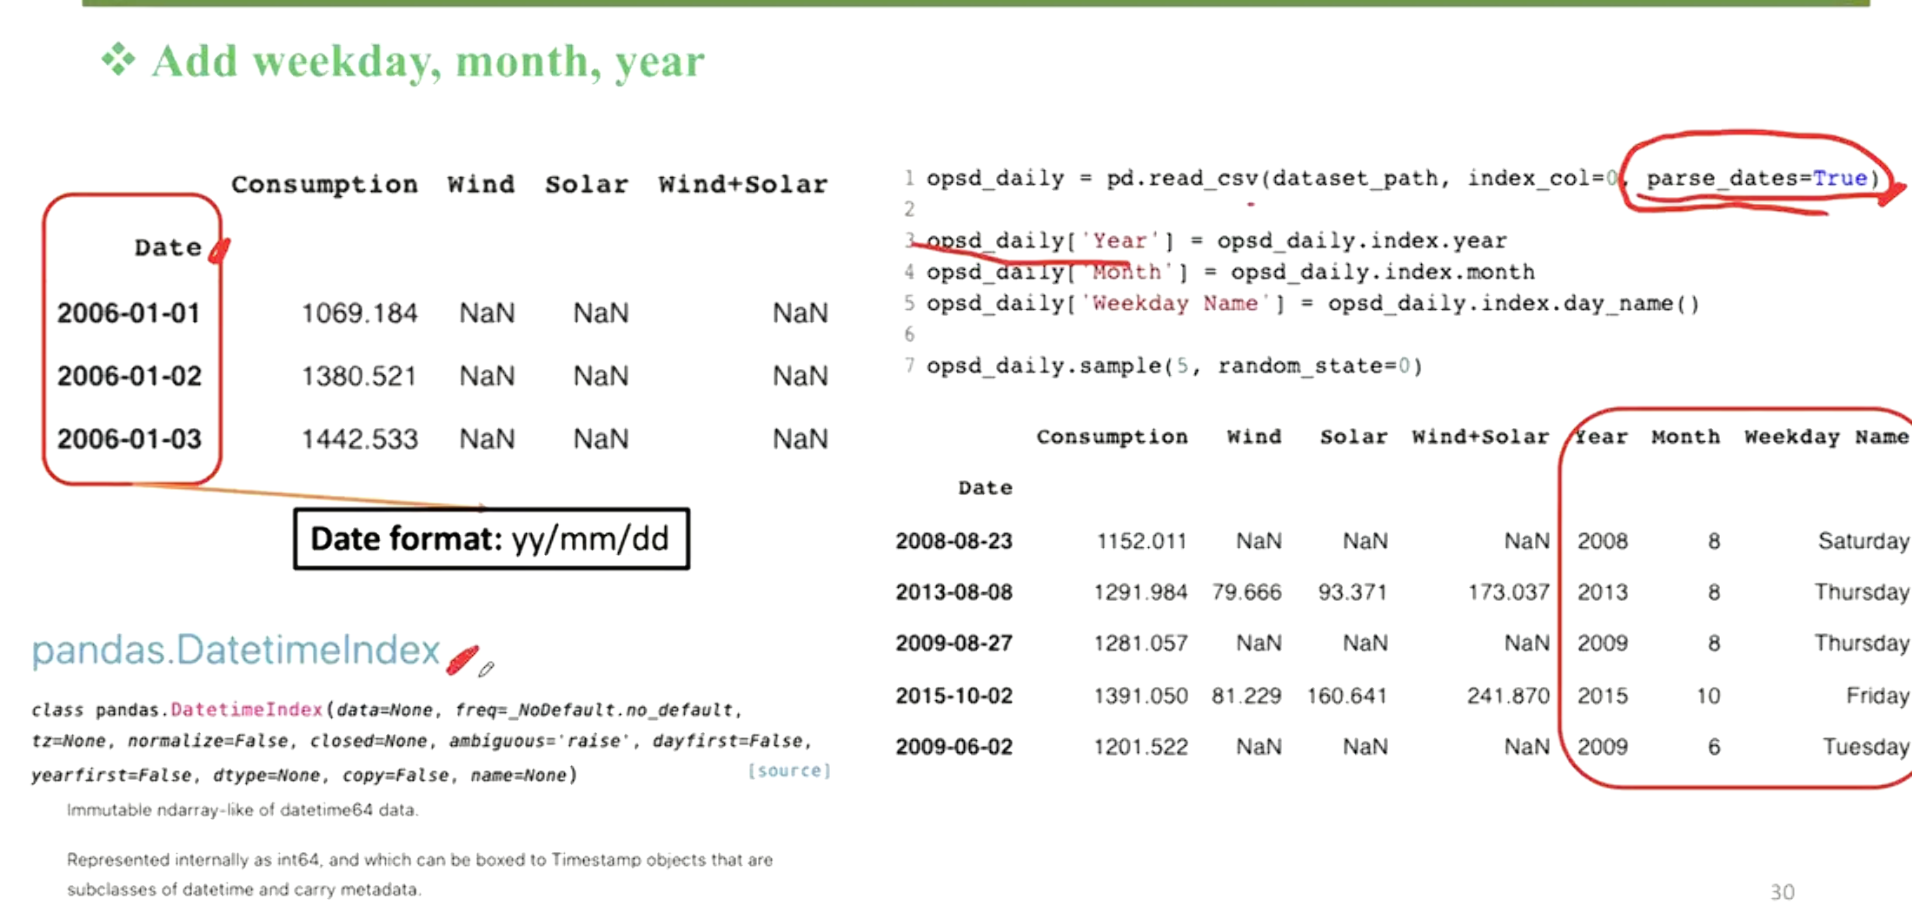

In [55]:
# Add weekday, month, year
opsd_daily = pd.read_csv(data_path, index_col=0,parse_dates=True)
opsd_daily['Year'] = opsd_daily.index.year 
opsd_daily['Month'] = opsd_daily.index.month
opsd_daily['Weekday Name'] = opsd_daily.index.day_name()

opsd_daily.head()

,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,2006,1,Sunday
2006-01-02,1380.521,NaN,NaN,NaN,2006,1,Monday
2006-01-03,1442.533,NaN,NaN,NaN,2006,1,Tuesday
2006-01-04,1457.217,NaN,NaN,NaN,2006,1,Wednesday
2006-01-05,1477.131,NaN,NaN,NaN,2006,1,Thursday


In [57]:
# Time-based indexing
opsd_daily.loc['2006-01-01':'2006-01-5']

,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,2006,1,Sunday
2006-01-02,1380.521,NaN,NaN,NaN,2006,1,Monday
2006-01-03,1442.533,NaN,NaN,NaN,2006,1,Tuesday
2006-01-04,1457.217,NaN,NaN,NaN,2006,1,Wednesday
2006-01-05,1477.131,NaN,NaN,NaN,2006,1,Thursday


In [59]:
opsd_daily.loc['2006-01'].head(10)

,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,2006,1,Sunday
2006-01-02,1380.521,NaN,NaN,NaN,2006,1,Monday
2006-01-03,1442.533,NaN,NaN,NaN,2006,1,Tuesday
2006-01-04,1457.217,NaN,NaN,NaN,2006,1,Wednesday
2006-01-05,1477.131,NaN,NaN,NaN,2006,1,Thursday
2006-01-06,1403.427,NaN,NaN,NaN,2006,1,Friday
2006-01-07,1300.287,NaN,NaN,NaN,2006,1,Saturday
2006-01-08,1207.985,NaN,NaN,NaN,2006,1,Sunday
2006-01-09,1529.323,NaN,NaN,NaN,2006,1,Monday


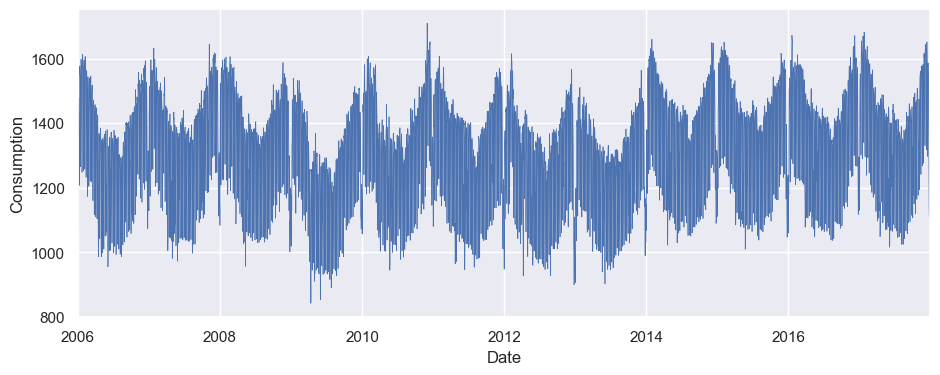

In [60]:
# Visualize time-series data
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(rc={'figure.figsize':(11,4)})
col_to_plot = 'Consumption'
opsd_daily[col_to_plot].plot(linewidth=0.5)
plt.ylabel(col_to_plot)
plt.show()

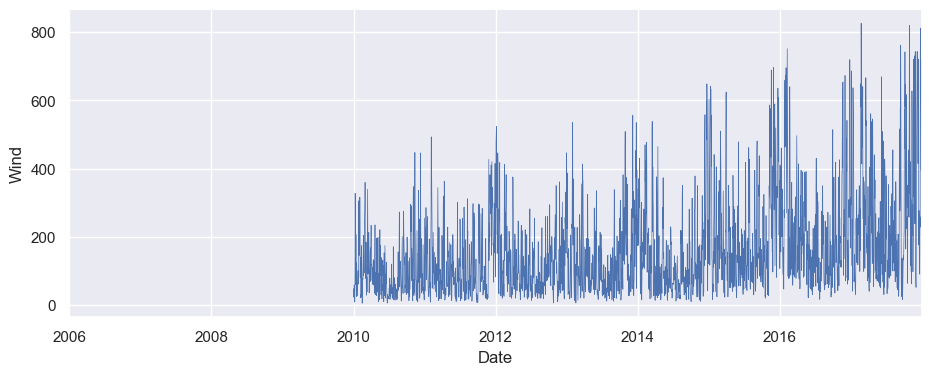

In [62]:
col_to_plot = 'Wind'
opsd_daily[col_to_plot].plot(linewidth=0.5)
plt.ylabel(col_to_plot)
plt.show()

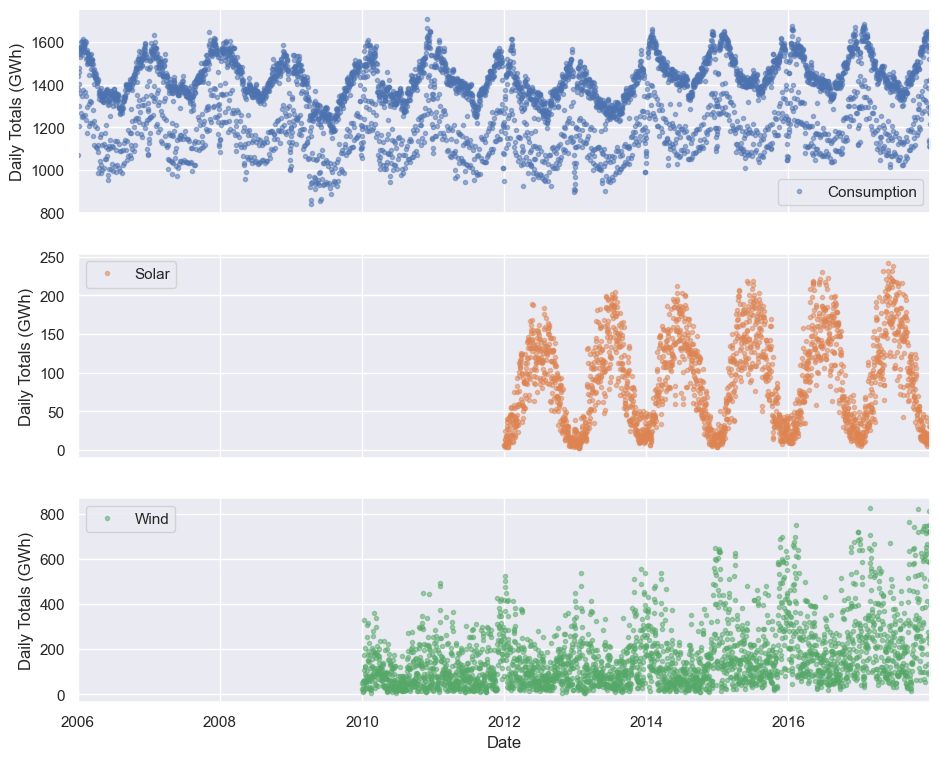

In [64]:
cols_plot = ['Consumption', 'Solar', 'Wind']
axes = opsd_daily[cols_plot].plot(
    marker='.',
    alpha=0.5,
    linestyle='None',
    figsize=(11, 9),
    subplots=True    
)
for ax in axes:
    ax.set_ylabel('Daily Totals (GWh)')

plt.show()

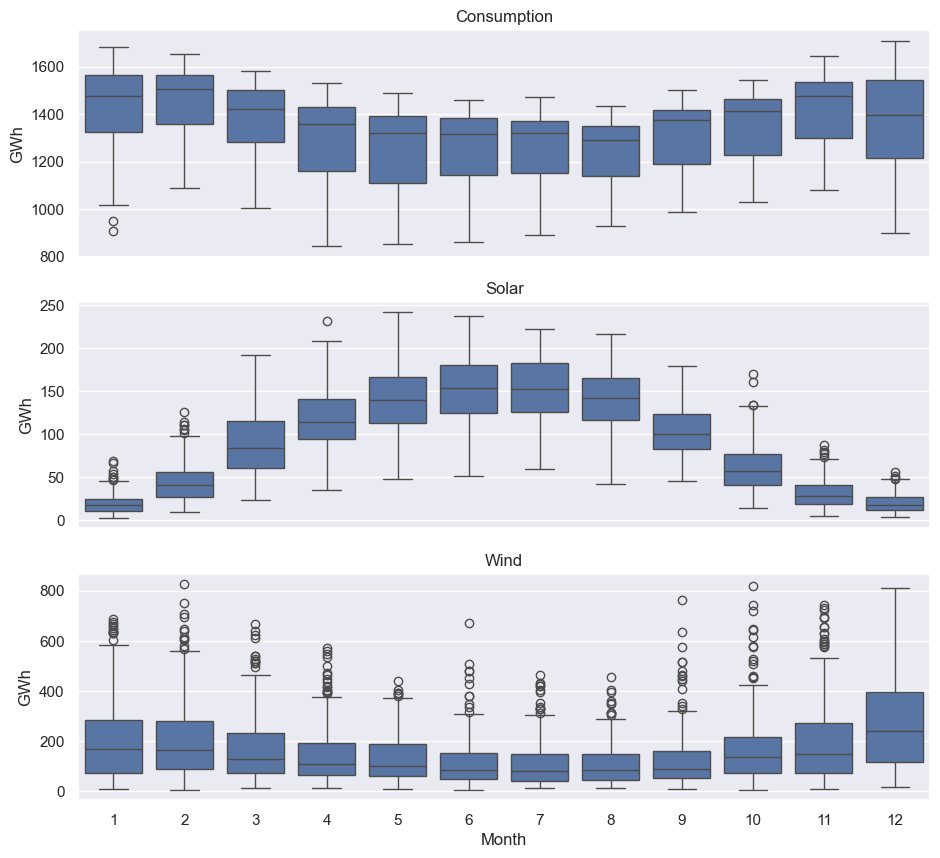

In [65]:
# Seasonality visualization
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for name, ax in zip(['Consumption', 'Solar', 'Wind'], axes):
    sns.boxplot(data=opsd_daily, x='Month',y=name,ax=ax)
    ax.set_ylabel('GWh')
    ax.set_title(name)

    if ax != axes[-1]:
        ax.set_xlabel('')

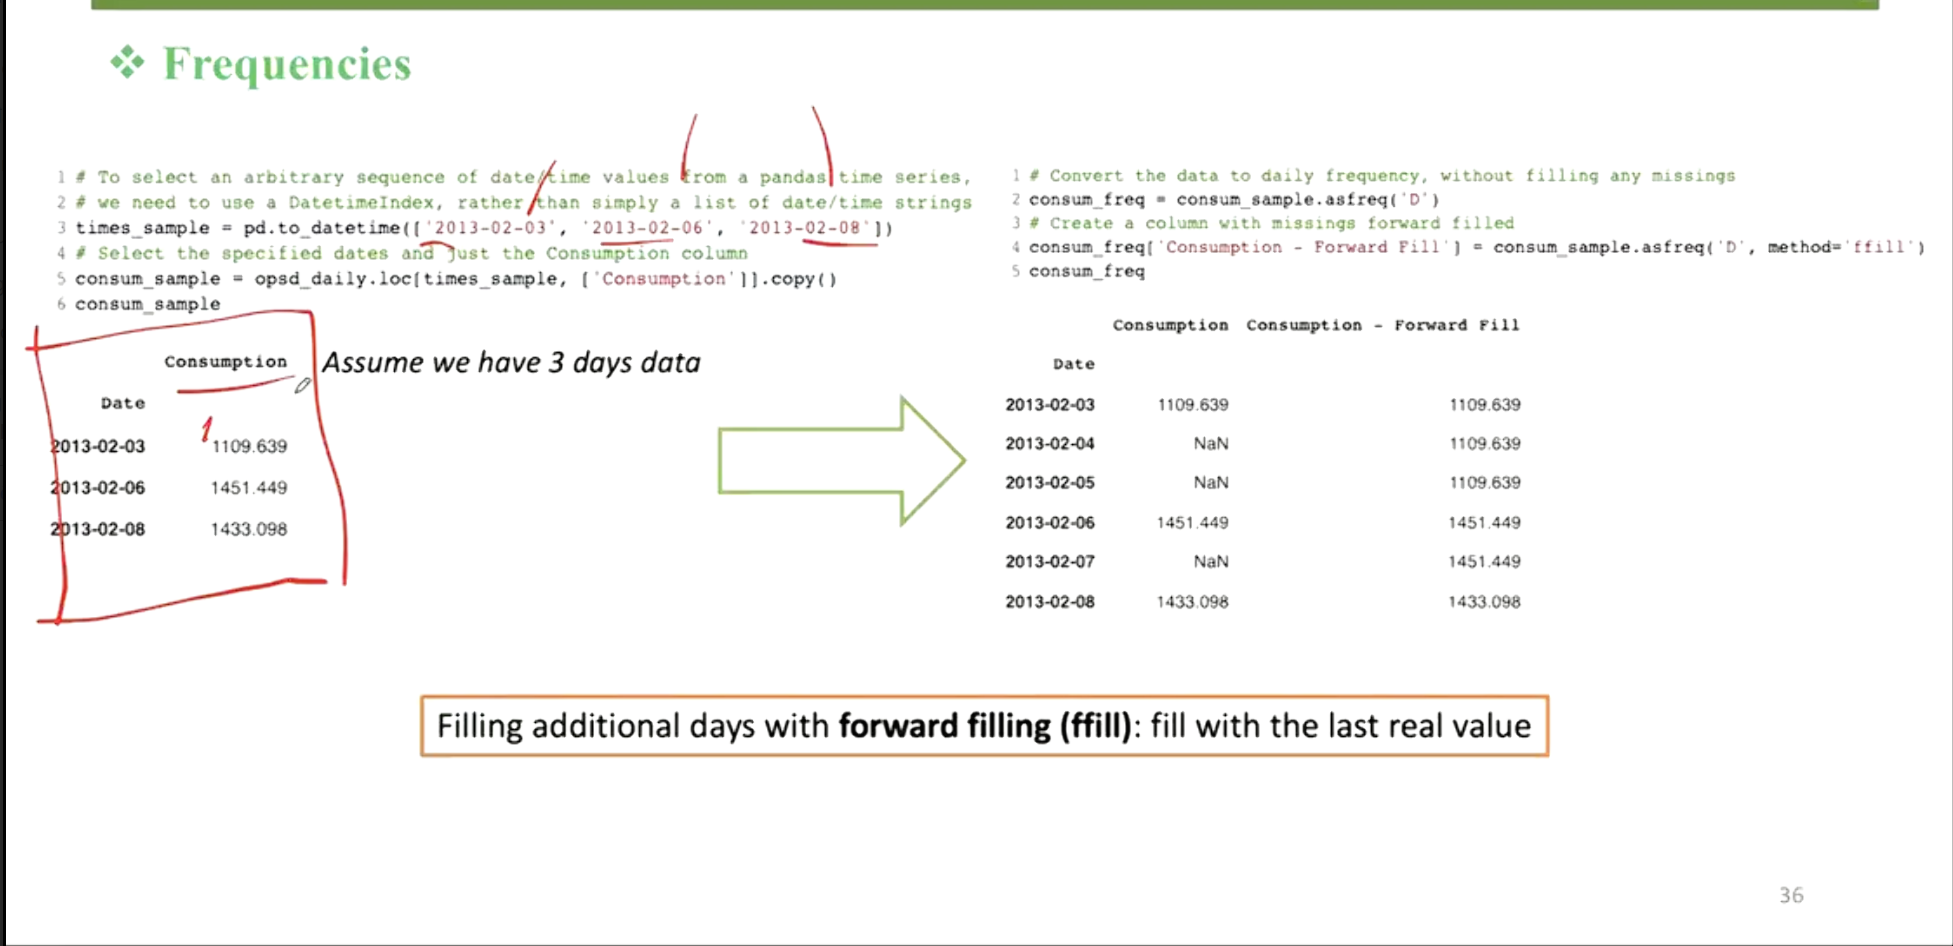

In [67]:
# Frequencies
# day frequency
pd.date_range('1998-03-10','1998-03-15',freq='D')

# hour frequency
pd.date_range('2004-09-20', periods=8, freq='H')

C:\Users\Nguyen\AppData\Local\Temp\ipykernel_22908\1810228440.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range('2004-09-20', periods=8, freq='H')


DatetimeIndex(['2004-09-20 00:00:00', '2004-09-20 01:00:00',
               '2004-09-20 02:00:00', '2004-09-20 03:00:00',
               '2004-09-20 04:00:00', '2004-09-20 05:00:00',
               '2004-09-20 06:00:00', '2004-09-20 07:00:00'],
              dtype='datetime64[ns]', freq='h')

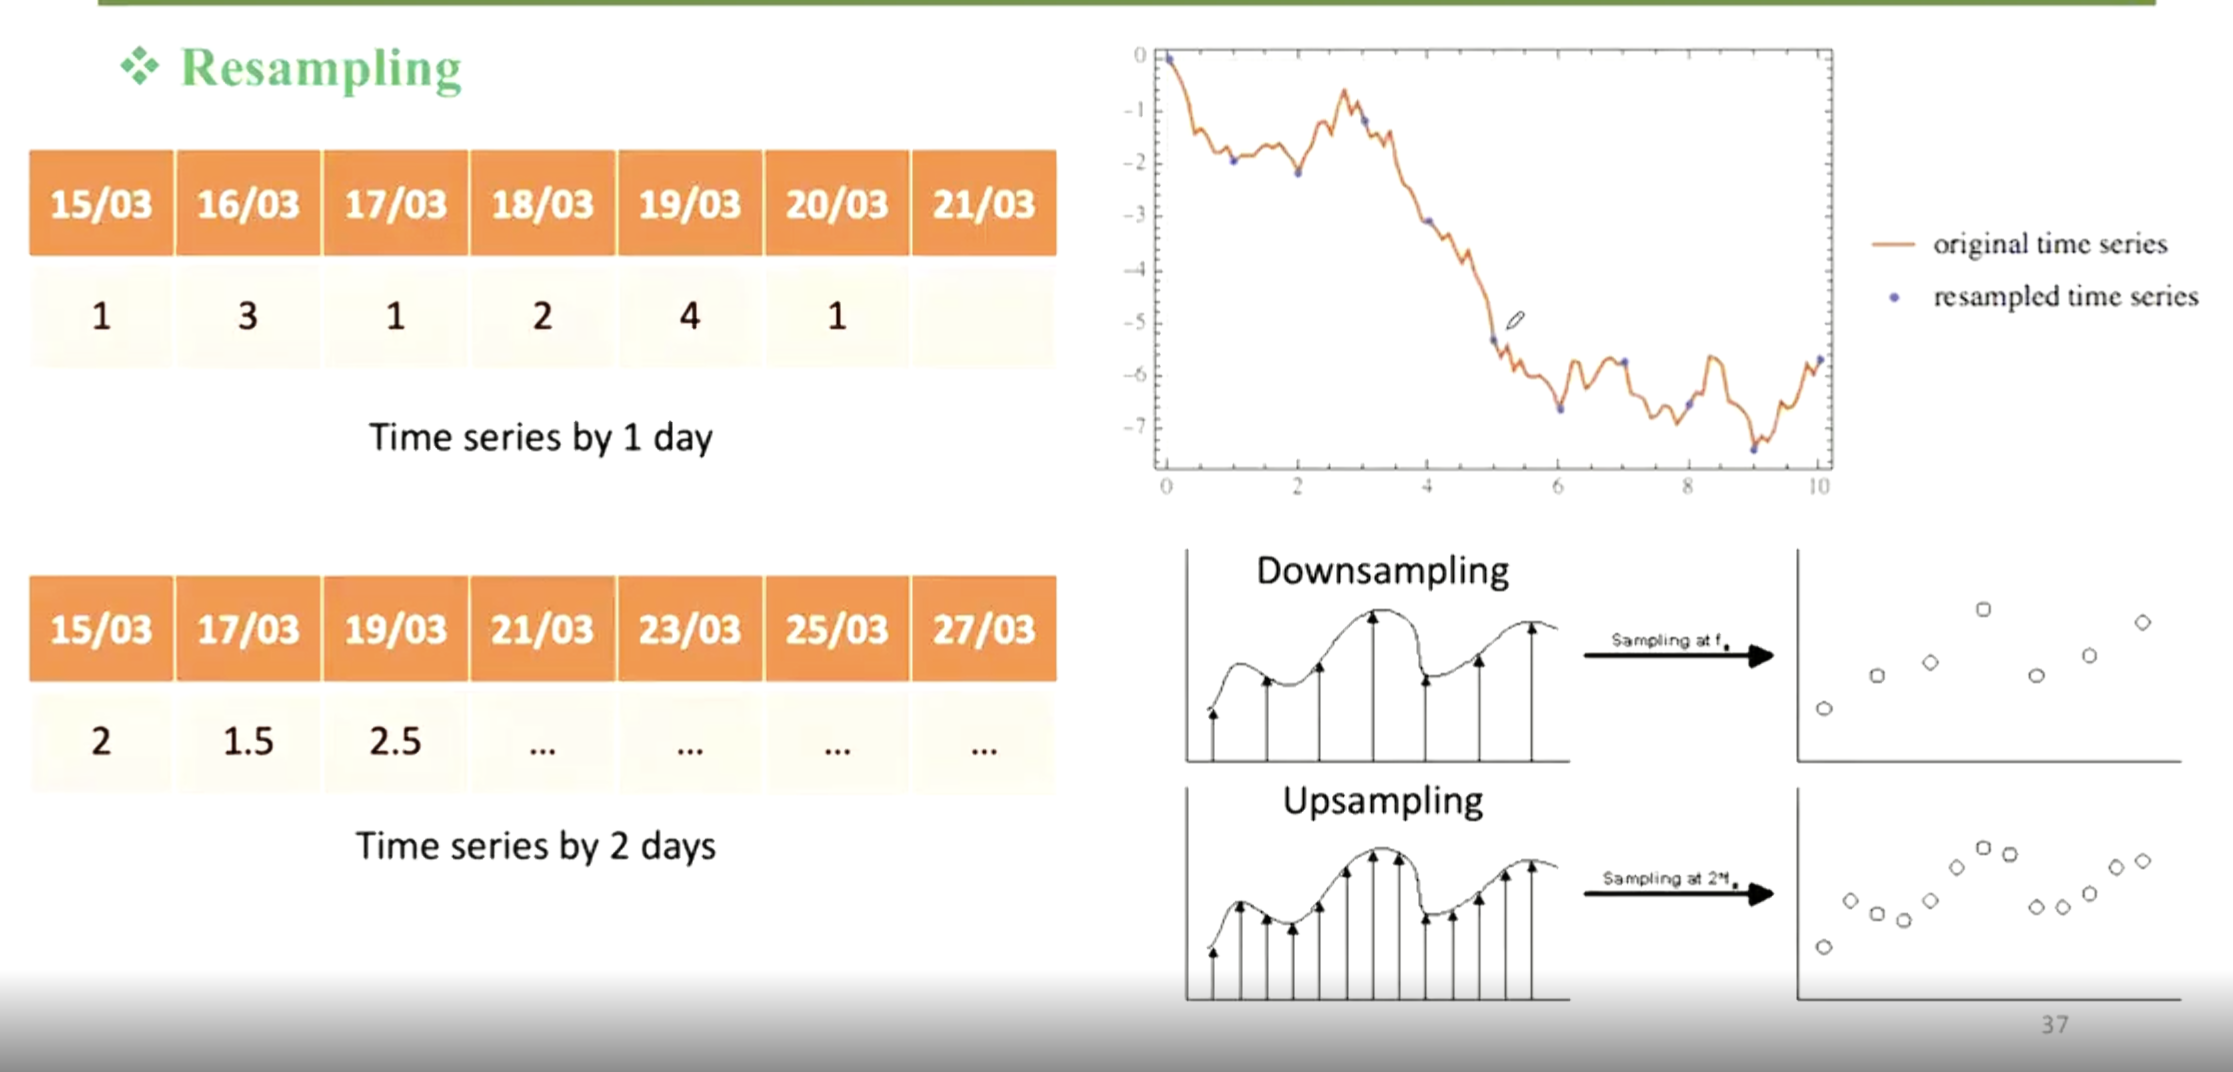
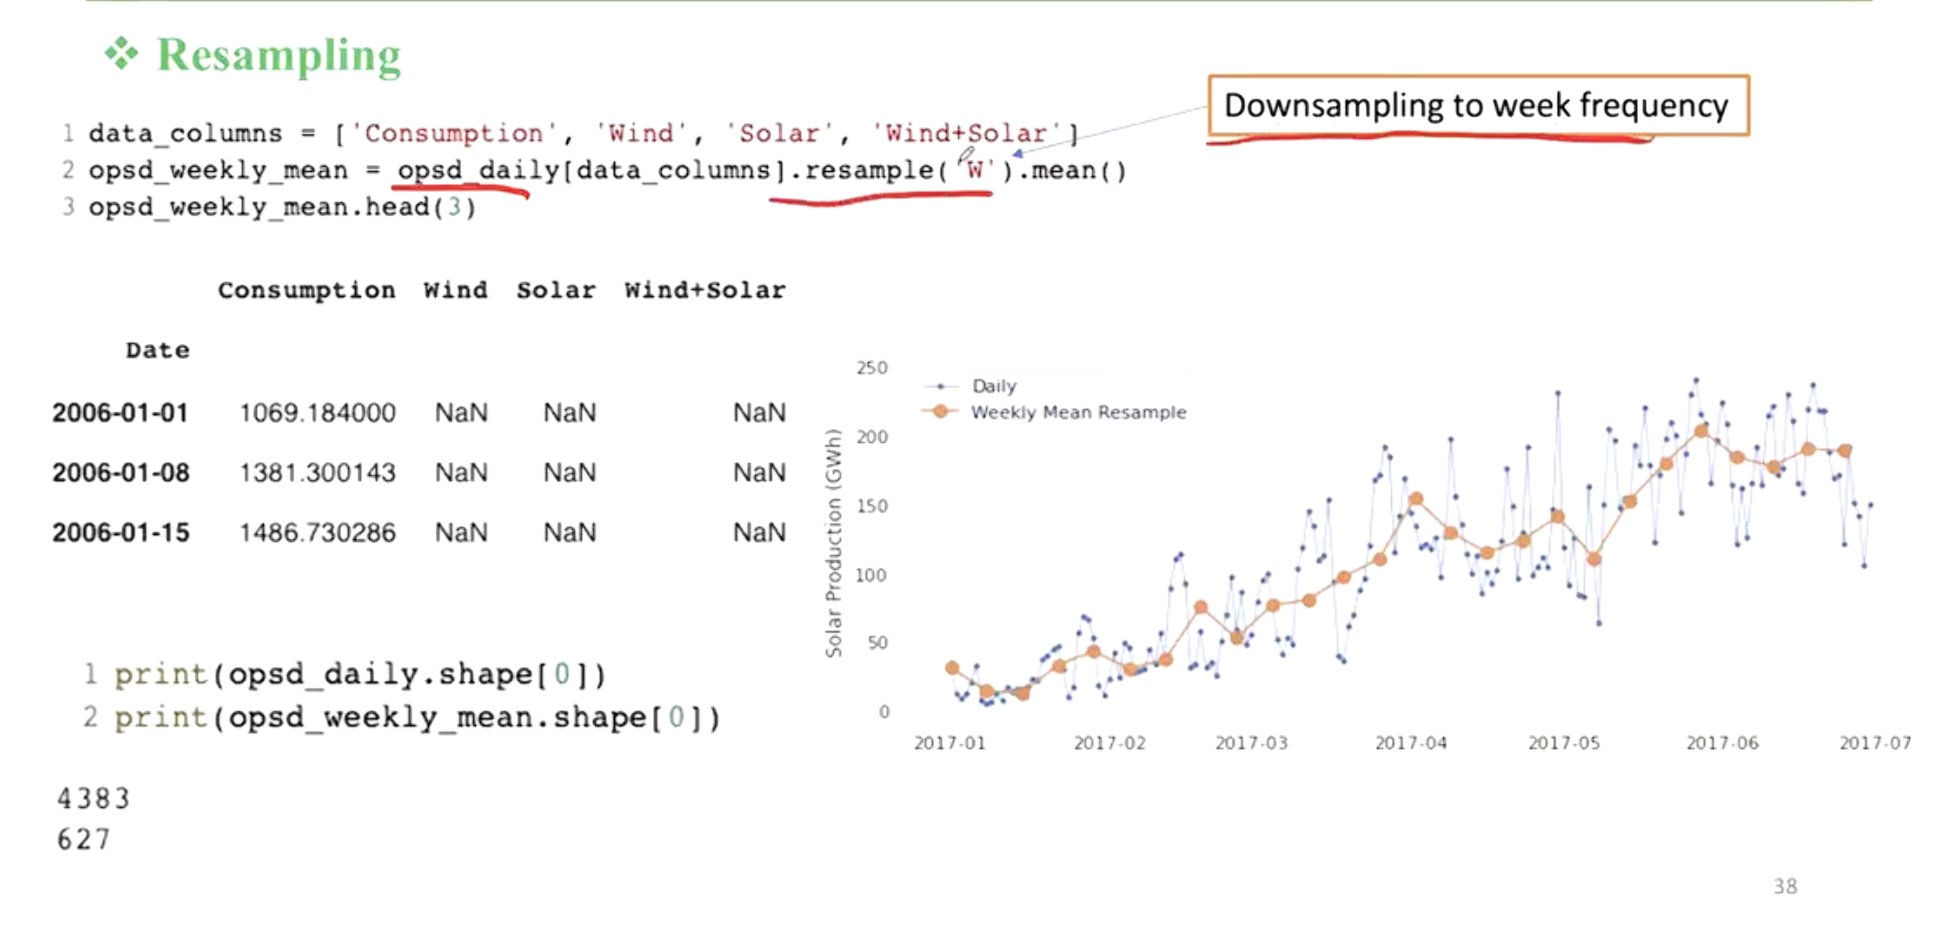
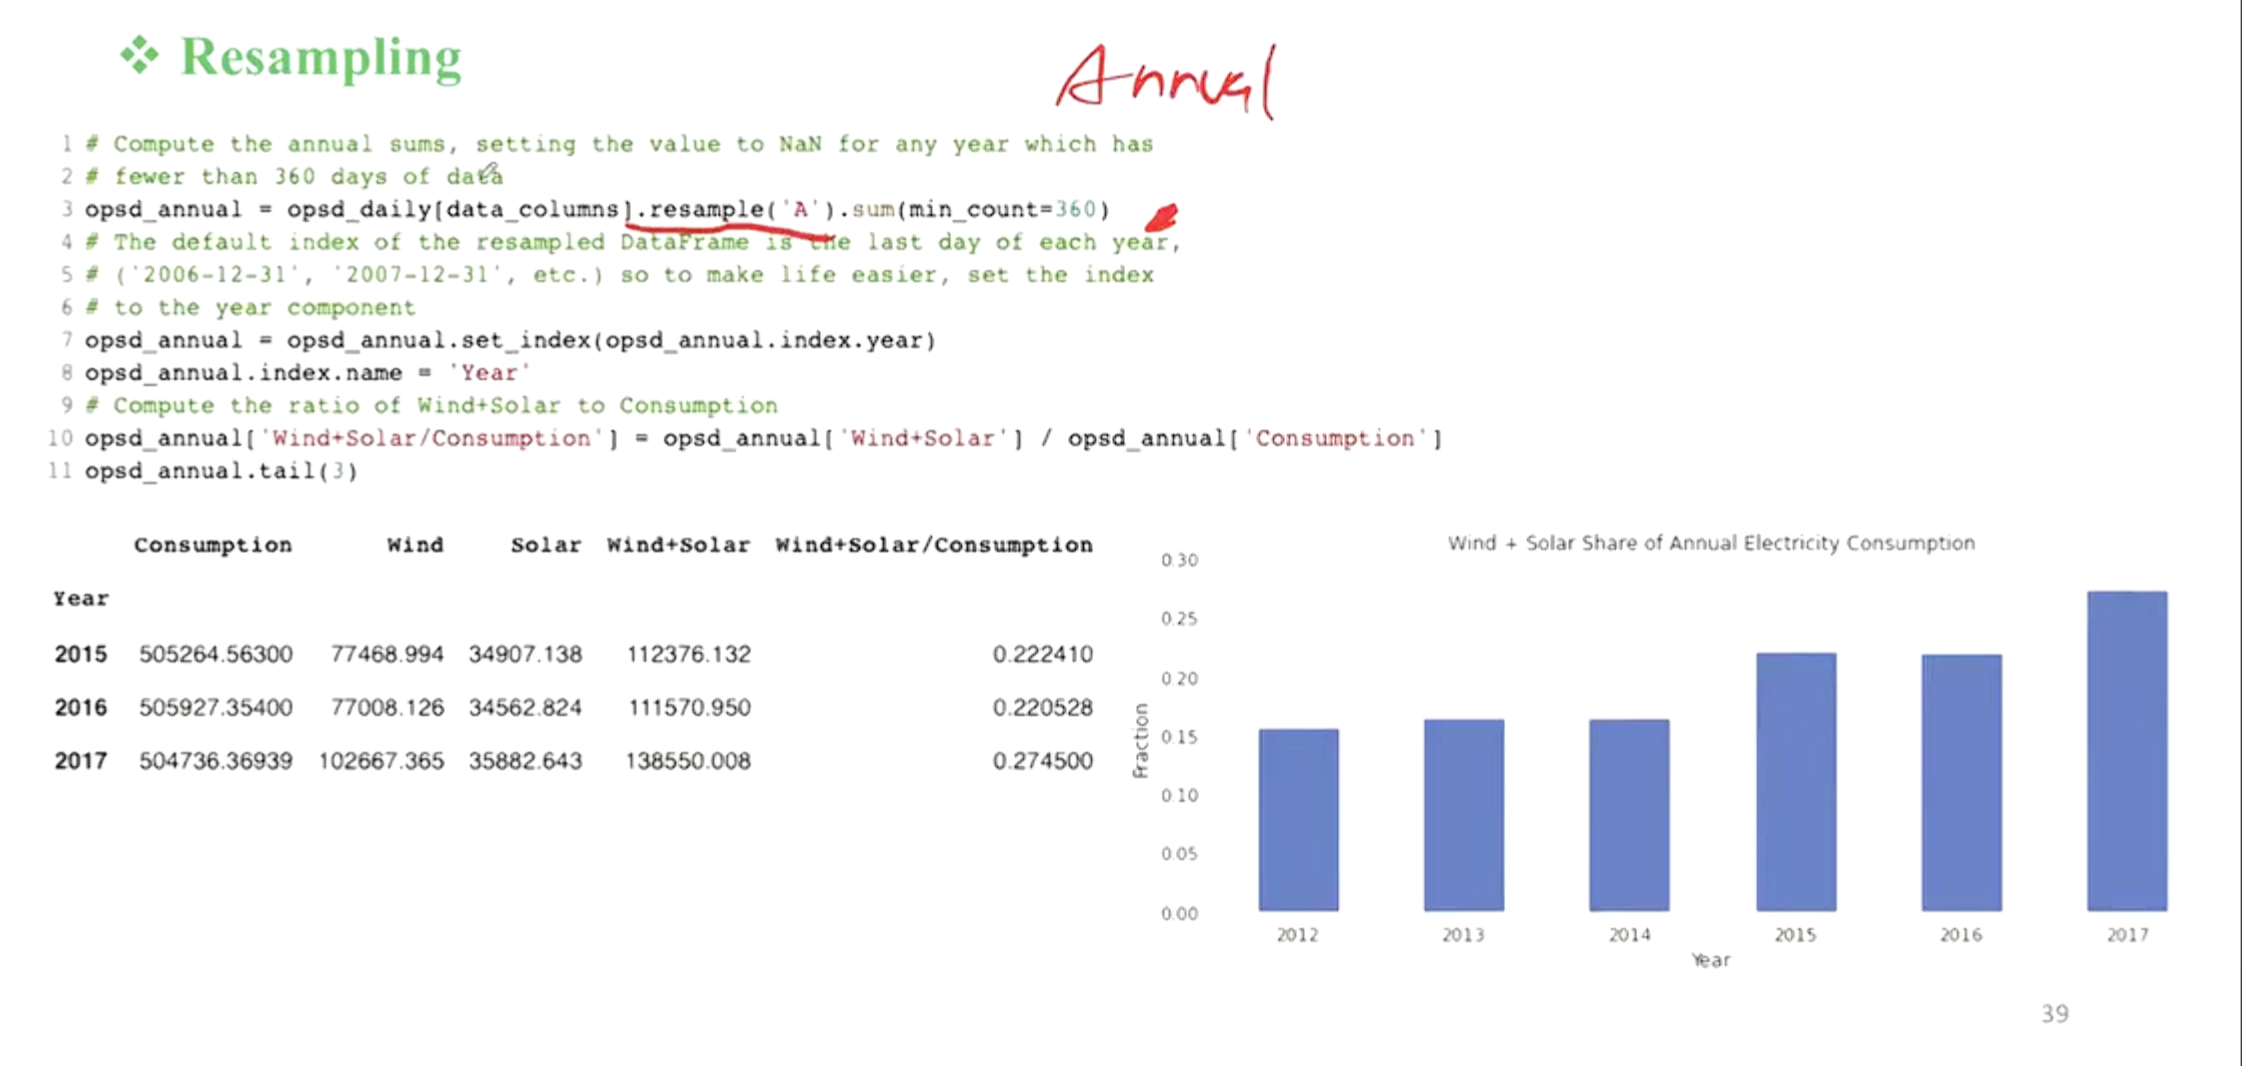
